In [1]:
import numpy as np
import os
import glob 
import time 
import pandas as pd
import shutil
import re
import mdtraj as md
import MDAnalysis as mda
import pickle
import pickle as p 
import csv
import sys
import subprocess
import xml.etree.ElementTree as ET
import requests
import concurrent.futures
import multiprocessing
import nglview as nv
import h5py
import matplotlib as mpl
import matplotlib.patheffects as path_effects
import matplotlib.patches as patches
import html
import biobox as bb
import tempfile
import matplotlib.pyplot as plt
import molearn
import torch
import glob as glob
import MDAnalysis.analysis.rms as rms
import seaborn as sns
import pickle
import networkx as nx
sys.path.insert(0, os.path.join(os.path.abspath(os.pardir),'src'))

from Bio import PDB
from tqdm import tqdm
from time import time as t
from urllib.request import urlretrieve as download
from Bio.Blast import NCBIWWW, NCBIXML
from Bio.Blast.Applications import NcbipsiblastCommandline
from collections import defaultdict
from Bio.PDB import PPBuilder
from Bio.SeqUtils import seq1
from modeller import *
from modeller.automodel import *
from Bio.PDB import PDBParser
from MDAnalysis.analysis import align
from mpi4py import MPI
from glob import glob
from pprint import pprint as pp
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from glob import glob as g
from tqdm.notebook import tqdm
from collections import Counter
from matplotlib.ticker import FuncFormatter
from collections import defaultdict
from pymol import cmd
from scipy.interpolate import interp1d
from mpl_toolkits import mplot3d
from scipy import stats
from sklearn.cluster import AgglomerativeClustering, SpectralClustering
from matplotlib.colors import BoundaryNorm
from numpy.linalg import norm
from molearn.data import PDBData
from molearn.trainers import Trainer
from molearn.models.small_foldingnet import Small_AutoEncoder
from molearn.analysis.analyser import MolearnAnalysis
from copy import deepcopy
from molearn.analysis import MolearnGUI
from scipy.ndimage import rotate
from numpy.linalg import inv
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_score
from itertools import combinations
from urllib.request import urlretrieve
from urllib.error import URLError
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.tree import export_graphviz
from sklearn import tree
from scipy.stats import pearsonr


/data/student/yuxiz/envs/project/lib/python3.10/site-packages/nglview/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


/data/student/yuxiz/envs/project/lib/python3.10/site-packages/molearn/trainers/sinkhorn_trainer.py:13: UserWarning: No module named 'geomloss'. Will not be able to use sinkhorn because geomloss is not installed.
  warnings.warn(f'{e}. Will not be able to use sinkhorn because geomloss is not installed.')


/data/student/yuxiz/envs/project/lib/python3.10/site-packages/molearn/scoring/__init__.py:26: UserWarning: No module named 'iotbx'. Will not be able to calculate Ramachandran score.
  warnings.warn(f"{e}. Will not be able to calculate Ramachandran score.")


Learning the conformational ensemble with an Autoencoder.

In [2]:
"""
This script trains a Small_AutoEncoder on a folder of aligned protein structures by first merging individual PDB files into a multi-model combined.pdb, selecting backbone atoms, and then splitting the dataset into fixed training and test sets using a manual random seed. It initializes a Trainer with the training data and iteratively trains the autoencoder, saving the best checkpoint and logging progress.
"""

#fixed splitting strategy
from copy import deepcopy
def train_autoencoder_on_folder(folder_name, checkpoint_suffix):
    print(f"\n Starting training on: {folder_name}")
    data = PDBData()

    # Get files, excluding combined.pdb
    files = sorted([
        f for f in os.listdir(folder_name) 
        if os.path.isfile(os.path.join(folder_name, f)) and f != 'combined.pdb'
    ])

    # Merge into combined.pdb
    combined_file_path = os.path.join(folder_name, 'combined.pdb')
    with open(combined_file_path, 'w') as combined_file:
        for i, filename in enumerate(files):
            file_path = os.path.join(folder_name, filename)
            with open(file_path, 'r') as file:
                lines = file.readlines()
                lines = [line for line in lines if not line.startswith(("MODEL", "END"))]

            combined_file.write(f'MODEL {i}\n')
            combined_file.writelines(lines)
            combined_file.write('ENDMDL\n')
        combined_file.write('END\n')

    # Load and prepare data
    data.import_pdb(filename=combined_file_path)
    data.fix_terminal()
    data.atomselect(atoms=['CA', 'C', 'N', 'CB', 'O'])
    data.prepare_dataset()
    print(data._mol)

    # Split data
    # Get indices
    # Assume combined.pdb contains N models
    num_models = data.dataset.shape[0]
    manual_seed = 25
    valid_ratio = 0.1  # Proportion of validation set

    # Set random seed and shuffle model indices
    indices = np.random.RandomState(seed=manual_seed).permutation(num_models)

    # Split according to ratio
    num_test = int(num_models * valid_ratio)
    test_indices = indices[:num_test]
    train_indices = indices[num_test:]

    # Save to text files
    np.savetxt(f"train_model_indices_{checkpoint_suffix}.txt", train_indices, fmt='%d')
    np.savetxt(f"test_model_indices_{checkpoint_suffix}.txt", test_indices, fmt='%d')

    # Create subset PDBData objects
    from copy import deepcopy
    data_train_obj = deepcopy(data)
    data_test_obj = deepcopy(data)
    data_train_obj.dataset = data.dataset[train_indices]
    data_test_obj.dataset = data.dataset[test_indices]
    print(f"NUM OF TRAIN SET: {len(data_train_obj.dataset)}")
    print("FINISH")

    # Set up trainer
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    trainer = Trainer(device=device)
    trainer.set_data(data_train_obj, batch_size=8, validation_split=0.1, manual_seed=25)
    trainer.set_autoencoder(Small_AutoEncoder, out_points=data.dataset.shape[-1])
    trainer.prepare_optimiser()

    # Set output folder path
    base_result_dir = f'Results/run_trial_BRAFActivationLoop_postalign_{checkpoint_suffix}'
    log_file = os.path.join(base_result_dir, 'xbb_foldingnet_checkpoints', 'log_file.dat')
    log_folder = os.path.join(base_result_dir, 'xbb_foldingnet_checkpoints')
    checkpoint_folder = base_result_dir

    os.makedirs(log_folder, exist_ok=True)

    # Start training
    best = 1e24
    while True:
        trainer.run(max_epochs=32 + trainer.epoch,
                    log_filename='log_file.dat',
                    log_folder=log_folder,
                    checkpoint_folder=checkpoint_folder)
        if not best > trainer.best:
            break
        best = trainer.best

    print(f" Training completed for {folder_name}")
    print(f"   Best loss: {trainer.best:.4f}")
    print(f"   Best checkpoint: {trainer.best_name}")

if __name__ == '__main__':
    # Path: RMSD ≤ 11
    folder = 'Results/fitted_matlab_segments/mustang_endsAlignment_cleaned_noOutliers'
    suffix = 'cleaned_noOutlier_11_checkpoint_newsplit'

    #Train
    train_autoencoder_on_folder(folder, suffix)



 Starting training on: Results/fitted_matlab_segments/mustang_endsAlignment_cleaned_noOutliers
Dataset.shape: torch.Size([1337, 3, 27])
mean: 109.51480491611034, std: 22.37727293899585
NUM OF TRAIN SET: 1204
FINISH
device: cpu


{"train_mse_loss": 0.32568445089668363, "train_loss": 0.32568445089668363, "valid_mse_loss": 0.127623375877738, "valid_loss": 0.127623375877738, "epoch": 0, "train_seconds": 6.283747673034668, "valid_seconds": 0.17560505867004395, "checkpoint_seconds": 0.28656458854675293, "total_seconds": 6.745917320251465}


{"train_mse_loss": 0.11220216871380147, "train_loss": 0.11220216871380147, "valid_mse_loss": 0.23058206836382547, "valid_loss": 0.23058206836382547, "epoch": 1, "train_seconds": 6.530759811401367, "valid_seconds": 0.1751856803894043, "checkpoint_seconds": 0.22847318649291992, "total_seconds": 6.934418678283691}


{"train_mse_loss": 0.09985440578380414, "train_loss": 0.09985440578380414, "valid_mse_loss": 5.28881713449955, "valid_loss": 5.28881713449955, "epoch": 2, "train_seconds": 6.573739767074585, "valid_seconds": 0.17736530303955078, "checkpoint_seconds": 0.2283010482788086, "total_seconds": 6.979406118392944}


{"train_mse_loss": 0.07058732842552266, "train_loss": 0.07058732842552266, "valid_mse_loss": 7.2467403666426735, "valid_loss": 7.2467403666426735, "epoch": 3, "train_seconds": 6.87251353263855, "valid_seconds": 0.17668962478637695, "checkpoint_seconds": 0.22258591651916504, "total_seconds": 7.271789073944092}


...

{"train_mse_loss": 0.040233532585396095, "train_loss": 0.040233532585396095, "valid_mse_loss": 0.09577717731396357, "valid_loss": 0.09577717731396357, "epoch": 59, "train_seconds": 6.732743501663208, "valid_seconds": 0.1800670623779297, "checkpoint_seconds": 0.22980546951293945, "total_seconds": 7.142616033554077}


{"train_mse_loss": 0.03937016747809424, "train_loss": 0.03937016747809424, "valid_mse_loss": 0.3202246457338333, "valid_loss": 0.3202246457338333, "epoch": 60, "train_seconds": 6.730417728424072, "valid_seconds": 0.1819934844970703, "checkpoint_seconds": 0.23283743858337402, "total_seconds": 7.145248651504517}


{"train_mse_loss": 0.06140251581409321, "train_loss": 0.06140251581409321, "valid_mse_loss": 0.07855565597613652, "valid_loss": 0.07855565597613652, "epoch": 61, "train_seconds": 6.739919424057007, "valid_seconds": 0.18145012855529785, "checkpoint_seconds": 0.23667335510253906, "total_seconds": 7.158042907714844}


{"train_mse_loss": 0.04982589581479555, "train_loss": 0.04982589581479555, "valid_mse_loss": 0.10091027518113455, "valid_loss": 0.10091027518113455, "epoch": 62, "train_seconds": 6.7305028438568115, "valid_seconds": 0.1830446720123291, "checkpoint_seconds": 0.22608375549316406, "total_seconds": 7.139631271362305}


{"train_mse_loss": 0.04849267410753618, "train_loss": 0.04849267410753618, "valid_mse_loss": 0.08743607675035794, "valid_loss": 0.08743607675035794, "epoch": 63, "train_seconds": 6.754556179046631, "valid_seconds": 0.18173527717590332, "checkpoint_seconds": 0.22723937034606934, "total_seconds": 7.1635308265686035}
 Training completed for Results/fitted_matlab_segments/mustang_endsAlignment_cleaned_noOutliers
   Best loss: 0.0259
   Best checkpoint: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/checkpoint_epoch28_loss0.025858852018912633.ckpt


In [3]:
import glob
file_pattern = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/checkpoint_*.ckpt'

print(glob.glob(file_pattern))

matching_files = sorted(glob.glob(file_pattern))

if len(matching_files) == 0:
    raise FileNotFoundError(f"No files matched the pattern: {file_pattern}")

networkfile = matching_files[0]

checkpoint = torch.load(networkfile, map_location=torch.device('cpu'), weights_only = False)
net = Small_AutoEncoder(**checkpoint['network_kwargs'])
net.load_state_dict(checkpoint['model_state_dict'])

print("Matched files:", matching_files)
print("Using file:", networkfile)
print("Network kwargs:", checkpoint['network_kwargs'])

['Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/checkpoint_epoch28_loss0.025858852018912633.ckpt', 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/checkpoint_epoch40_loss0.032078755026062326.ckpt', 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/checkpoint_epoch123_loss0.036649541929364204.ckpt']
Matched files: ['Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/checkpoint_epoch123_loss0.036649541929364204.ckpt', 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/checkpoint_epoch28_loss0.025858852018912633.ckpt', 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/checkpoint_epoch40_loss0.032078755026062326.ckpt']
Using file: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/checkpoint_epoch123_loss0.036649541929364

In [4]:
import os
data = PDBData()
folder_name = 'Results/fitted_matlab_segments/mustang_endsAlignment_cleaned_noOutliers'
combined_file_path = os.path.join(folder_name, 'combined.pdb')
data.import_pdb(filename=combined_file_path)
data.fix_terminal()
data.atomselect(atoms = ['CA', 'C', 'N', 'CB', 'O'])
data.prepare_dataset()

Dataset.shape: torch.Size([1337, 3, 27])
mean: 109.51480491611034, std: 22.37727293899585


In [5]:
from copy import deepcopy
MA = MolearnAnalysis()
MA.set_network(net)

checkpoint_suffix = 'cleaned_noOutlier_11_checkpoint_newsplit'
train_file = f"train_model_indices_{checkpoint_suffix}.txt"
test_file = f"test_model_indices_{checkpoint_suffix}.txt"

train_indices = np.loadtxt(train_file, dtype=int)
test_indices = np.loadtxt(test_file, dtype=int)

print("Train indices loaded:", train_indices.shape)
print("Test indices loaded:", test_indices.shape)
print(test_indices)

data_train = deepcopy(data)
data_test = deepcopy(data)
data_train.dataset = data.dataset[train_indices]
data_test.dataset = data.dataset[test_indices]
data_train.indices = train_indices
data_test.indices = test_indices

MA.set_dataset("training", data_train)
MA.set_dataset("test", data_test)


Train indices loaded: (1204,)
Test indices loaded: (133,)
[ 747  633  651  411  502  471  595  425 1102 1317  163  935 1128  766
  104 1289 1119  221   77  314  201   69  596  515  675 1200  424 1045
 1157  634  703  223  795  773 1131  444  260  373  357  885 1096  664
  691  119  827 1327  605  889  705  194  469 1255  280  522  120  657
  834  271  141 1281  561 1027  805 1101  157 1004  853    7  349  869
  279 1239  302   39 1312  126  219  100  400 1144 1214  420  549  768
  259  948 1014  929   92 1235 1298 1264  793   74  983  370  270  123
 1055  944  609  532 1240  195 1149 1108 1247  810  113 1301   64  674
  624  132 1123  203  784 1245   16 1166  932 1120 1141  419 1097  253
  343  706  440  479  671  333  162]


In [6]:
"""
Save structures for training dataset
"""
def ifnotmake(dir_path):
    if not os.path.isdir(dir_path):
        os.makedirs(dir_path)
    return dir_path

print(sorted(np.append(train_indices, test_indices)))

ifnotmake('Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/')
for i, index in enumerate(train_indices):
    print(index)
    data._mol.set_current(index)  # Switch to the frame at the given index
    pdb_lines = data._mol.get_pdb_data() 
    with open(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/s{i}.pdb', 'w') as f:
        for line in pdb_lines:
            if isinstance(line, list) and line[0] == 'ATOM':
                atom_serial = line[1]
                atom_name = line[2]
                res_name = line[3]
                chain_id = line[4]
                res_seq = line[5]
                x, y, z = line[6:9]
                occupancy = line[10]
                b_factor = line[9]
                element = line[11]

                pdb_line = f"{'ATOM':<6}{atom_serial:>5} {atom_name:^4}{res_name:>4} {chain_id}{res_seq:>4}    {x:8.3f}{y:8.3f}{z:8.3f}{occupancy:6.2f}{b_factor:6.2f}          {element:>2}"
                f.write(pdb_line + '\n')
    

    

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

455
273
552
172
963
855
1105
1174
973


371
414
754
553
492
161
1189
942
1265
708
249
1003
958
286
1012
138
477
1113
949
166
421
716
1260
1169
746
647
593
21
1139
1237
153
336
518
955
1069
670
1040
938
847
241
1010
776
456
906
1262
625
431
1025
1033
1023
415
993
213
801
196
1193
1192
238
1196
466
1126
722
887
898
297
15
613
939
697
449
190
1021
952
646
174
1017
307
409
639
1325
187
924
774
234
1116
330
987
1172
1011
228


237
295
108
169
656


672
945
618
199
410
1188
211
1142


...

1046
806
976
856
291
240


508
1292
668
309
1306
895
789
82
1066
760
1251
571


294
1322
990
350
352
1165
50
25


375
89
877
832
842
499
1219
1032
914
1132
833
1329
566
643
896


230
193
1323
1039
368
430
383
611
1125
20
640
1088
434
320
669
342
52
1330
272
384
840
729
1226
55
289
146
339
583
1015
1053
214
695
1163
147
517
160
79
451
777
251
429
300
44
514
67
62
565
1070
781
925
1253
693
883
1198
600
1100
526
783
327
782
306
933
14
970
723
1236
602
171
1008
22
1081
261
1154
628
678
752
235
872
997
804
604
1130
303
828
1184
649
548
981
562
109
1225
304
1324
406
769
131
813
852
1283
951
1112
167
641
453
500
927
1277
1180
1160
765
940
1175
255
886
143
474
318
1156


In [7]:
"""
Save structures for test dataset
"""
ifnotmake('Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test/')
for i, index in enumerate(test_indices):
    print(index)
    data._mol.set_current(index) 
    pdb_lines = data._mol.get_pdb_data() 
    with open(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test/s{i}.pdb', 'w') as f:
        for line in pdb_lines:
            if isinstance(line, list) and line[0] == 'ATOM':
                atom_serial = line[1]
                atom_name = line[2]
                res_name = line[3]
                chain_id = line[4]
                res_seq = line[5]
                x, y, z = line[6:9]
                occupancy = line[10]
                b_factor = line[9]
                element = line[11]

                pdb_line = f"{'ATOM':<6}{atom_serial:>5} {atom_name:^4}{res_name:>4} {chain_id}{res_seq:>4}    {x:8.3f}{y:8.3f}{z:8.3f}{occupancy:6.2f}{b_factor:6.2f}          {element:>2}"
                f.write(pdb_line + '\n')

747
633
651
411
502
471
595
425
1102
1317
163
935
1128
766
104
1289
1119
221
77
314
201
69
596
515
675
1200
424


1045
1157
634
703
223


795
773
1131
444
260
373
357
885
1096
664
691


119
827
1327
605
889
705
194
469
1255


280
522
120
657
834
271
141
1281
561
1027
805
1101
157
1004


853
7
349
869
279
1239
302
39
1312
126
219
100
400
1144
1214
420
549
768
259
948
1014
929
92
1235
1298
1264
793
74
983
370
270
123
1055
944
609
532
1240
195
1149
1108
1247
810
113
1301
64
674
624
132
1123
203
784
1245
16
1166
932
1120
1141
419
1097
253
343
706
440
479
671
333
162


In [8]:
directory_name = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train'

# Create the output directory if it doesn't exist
ifnotmake(directory_name)

# Get latent coordinates from the trained model (2D latent space for training set)
latent_coords = MA.get_encoded('training') 

print(latent_coords)

# Generate reconstructed 3D coordinates from the latent coordinates
crd_ref = MA.generate(latent_coords.numpy().reshape(1, len(latent_coords), 2))

# Load the original multi-model structure (combined.pdb) as a trajectory
u = mda.Universe(combined_file_path)

# For each structure in the training set
for i, idx in enumerate(train_indices):
    coords = crd_ref[i]             # Get reconstructed coordinates
    u.trajectory[idx]               # Switch to the correct frame in the trajectory

    mol = u.select_atoms("name CA")  # Select C-alpha atoms only
    mol.positions = coords           # Replace coordinates with reconstructed ones

    mol.write(os.path.join(directory_name, f"s{i}.pdb")) 

encoding training:   0%|          | 0/1204 [00:00<?, ?it/s]

encoding training:   3%|▎         | 38/1204 [00:00<00:03, 326.53it/s]

encoding training:   7%|▋         | 79/1204 [00:00<00:03, 370.07it/s]

encoding training:  10%|█         | 125/1204 [00:00<00:02, 408.58it/s]

encoding training:  14%|█▍        | 171/1204 [00:00<00:02, 428.06it/s]

...

encoding training:  90%|█████████ | 1086/1204 [00:02<00:00, 449.31it/s]

encoding training:  94%|█████████▍| 1131/1204 [00:02<00:00, 448.34it/s]

encoding training:  98%|█████████▊| 1176/1204 [00:02<00:00, 448.11it/s]

encoding training: 100%|██████████| 1204/1204 [00:02<00:00, 443.78it/s]

tensor([[[ 1.2300],
         [ 2.2322]],

        [[ 5.9856],
         [ 0.2789]],

        [[ 3.3433],
         [-0.3232]],

        ...,

        [[ 1.8779],
         [-2.2695]],

        [[ 3.3187],
         [-9.8294]],

        [[ 4.0399],
         [ 8.5647]]])


In [9]:
"""
Apply the same function to the test dataset as used for training.
"""
directory_name = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_test'

ifnotmake(directory_name)

latent_coords = MA.get_encoded('test') 

print(latent_coords)

crd_ref = MA.generate(latent_coords.numpy().reshape(1, len(latent_coords), 2))

u = mda.Universe(combined_file_path)

for i, idx in enumerate(test_indices):
    coords = crd_ref[i]             
    u.trajectory[idx]             

    mol = u.select_atoms("name CA")  
    mol.positions = coords       

    mol.write(os.path.join(directory_name, f"s{i}.pdb")) 

encoding test:   0%|          | 0/133 [00:00<?, ?it/s]

encoding test:  34%|███▍      | 45/133 [00:00<00:00, 443.84it/s]

encoding test:  68%|██████▊   | 90/133 [00:00<00:00, 401.25it/s]

encoding test:  98%|█████████▊| 131/133 [00:00<00:00, 376.52it/s]

encoding test: 100%|██████████| 133/133 [00:00<00:00, 383.22it/s]

tensor([[[ 1.6509e+00],
         [ 2.8955e+00]],

        [[ 1.2762e+01],
         [ 2.5793e+01]],

        [[ 1.3272e+00],
         [ 2.2086e+00]],

        [[ 6.4760e-01],
         [-6.4009e+00]],

        [[ 1.7926e+00],
         [-9.8022e+00]],

        [[ 1.3683e+01],
         [ 2.7067e+01]],

        [[ 1.4101e+01],
         [ 3.3561e+01]],

        [[ 1.7773e+00],
         [-1.0291e+01]],

        [[ 2.2059e+00],
         [ 4.0975e+00]],

        [[-8.6344e+01],
         [-1.2284e+02]],

        [[-1.2645e-02],
         [-4.6583e+00]],

        [[ 1.4104e+00],
         [-3.4627e+00]],

        [[ 4.8714e+00],
         [-2.0135e+00]],

        [[ 2.3329e+00],
         [ 4.8124e+00]],

        [[ 4.4133e+00],
         [-1.9565e+00]],

        [[ 7.6926e-01],
         [ 3.1181e+00]],

        [[ 2.2694e+01],
         [ 1.2113e+01]],

        [[ 1.4196e+00],
         [-1.0901e+01]],

        [[ 4.6831e+00],
         [ 1.0681e+01]],

        [[ 1.0280e+00],
         [-2.7497e-01]],



In [10]:
#Calculate RMSD for training dataset
getDatasetTrial_dir = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/'
decoded_train_dir = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train'

getDatasetTrial_files = os.listdir(getDatasetTrial_dir)
decoded_train_files = os.listdir(decoded_train_dir)

decoded_train_files = [f for f in decoded_train_files if f.startswith('s')]

def extract_number(file_name):
    match = re.search(r'\d+', file_name)
    return int(match.group()) if match else float('inf')

getDatasetTrial_files.sort(key=extract_number)
decoded_train_files.sort(key=extract_number)

rmsd_values = {}

for file_name in getDatasetTrial_files:
    if file_name in decoded_train_files:
        u1 = mda.Universe(os.path.join(getDatasetTrial_dir, file_name))
        u2 = mda.Universe(os.path.join(decoded_train_dir, file_name))
        
        ag1 = u1.select_atoms("name CA")
        ag2 = u2.select_atoms("name CA")
        
        rmsd_value = rms.rmsd(ag1.positions, ag2.positions)
        rmsd_values[file_name] = rmsd_value

for file_name in sorted(rmsd_values.keys(), key=extract_number):
    print(f"RMSD for {file_name}: {rmsd_values[file_name]}")


RMSD for s0.pdb: 5.655560458877775
RMSD for s1.pdb: 4.195411142832688
RMSD for s2.pdb: 5.9806358682990854
RMSD for s3.pdb: 4.519175033197487
RMSD for s4.pdb: 4.740646118490218
RMSD for s5.pdb: 4.635426811608645
RMSD for s6.pdb: 4.581577621079473
RMSD for s7.pdb: 4.156702900763706
RMSD for s8.pdb: 4.243952914805755
RMSD for s9.pdb: 4.8016647777855175
RMSD for s10.pdb: 2.8132446271956297
RMSD for s11.pdb: 4.760190892534241
RMSD for s12.pdb: 5.592134938780407
RMSD for s13.pdb: 5.973228566644445
RMSD for s14.pdb: 4.174886051362236
RMSD for s15.pdb: 5.967125260849976
RMSD for s16.pdb: 3.5370488674441867
RMSD for s17.pdb: 9.197873826212938
RMSD for s18.pdb: 3.8502759278743888
RMSD for s19.pdb: 6.078705490779602
RMSD for s20.pdb: 9.516491444938824
RMSD for s21.pdb: 5.403140611290085
RMSD for s22.pdb: 3.949889323564772
RMSD for s23.pdb: 5.000667015892024
RMSD for s24.pdb: 4.757187196643382
RMSD for s25.pdb: 3.7531670298804825
RMSD for s26.pdb: 4.1749058831762715
RMSD for s27.pdb: 37.9996042571

In [11]:
#Calculate RMSD for test dataset
getDatasetTrial_dir = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test/'
decoded_test_dir = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_test'

getDatasetTrial_files = os.listdir(getDatasetTrial_dir)
decoded_test_files = os.listdir(decoded_test_dir)

decoded_test_files = [f for f in decoded_test_files if f.startswith('s')]

def extract_number(file_name):
    match = re.search(r'\d+', file_name)
    return int(match.group()) if match else float('inf')

getDatasetTrial_files.sort(key=extract_number)
decoded_test_files.sort(key=extract_number)

rmsd_values = {}

for file_name in getDatasetTrial_files:
    if file_name in decoded_test_files:

        u1 = mda.Universe(os.path.join(getDatasetTrial_dir, file_name))
        u2 = mda.Universe(os.path.join(decoded_test_dir, file_name))
        
        ag1 = u1.select_atoms("name CA")
        ag2 = u2.select_atoms("name CA")
        
        rmsd_value = rms.rmsd(ag1.positions, ag2.positions)
        rmsd_values[file_name] = rmsd_value

for file_name in sorted(rmsd_values.keys(), key=extract_number):
    print(f"RMSD for {file_name}: {rmsd_values[file_name]}")


RMSD for s0.pdb: 4.2156308702220215
RMSD for s1.pdb: 4.338427685854535
RMSD for s2.pdb: 4.799079549059567
RMSD for s3.pdb: 4.649113821780639
RMSD for s4.pdb: 4.686926040498101
RMSD for s5.pdb: 3.9777145786273085
RMSD for s6.pdb: 9.384305585491884
RMSD for s7.pdb: 4.7454214444236165
RMSD for s8.pdb: 4.63558660561802
RMSD for s9.pdb: 40.18086287439373
RMSD for s10.pdb: 4.386819996634407
RMSD for s11.pdb: 2.831774876310256
RMSD for s12.pdb: 4.3797983492915185
RMSD for s13.pdb: 4.326780459650561
RMSD for s14.pdb: 3.69624056636143
RMSD for s15.pdb: 5.751873658034377
RMSD for s16.pdb: 6.074627558341735
RMSD for s17.pdb: 4.689298943409928
RMSD for s18.pdb: 4.4532169318199974
RMSD for s19.pdb: 5.257263429777282
RMSD for s20.pdb: 4.525214733916892
RMSD for s21.pdb: 7.869520320941043
RMSD for s22.pdb: 3.895699000395146
RMSD for s23.pdb: 3.5255696712988436
RMSD for s24.pdb: 3.747346645904341
RMSD for s25.pdb: 82.33670010414016
RMSD for s26.pdb: 7.257542403018311
RMSD for s27.pdb: 4.70229167048774

In [12]:
print(list(MA.get_error('training', align=False)))

Decoding training:   0%|          | 0/1204 [00:00<?, ?it/s]

Decoding training:   3%|▎         | 37/1204 [00:00<00:03, 366.05it/s]

Decoding training:   6%|▌         | 74/1204 [00:00<00:03, 358.39it/s]

Decoding training:   9%|▉         | 110/1204 [00:00<00:03, 352.96it/s]

Decoding training:  12%|█▏        | 147/1204 [00:00<00:02, 356.44it/s]

...

Decoding training:  90%|████████▉ | 1082/1204 [00:02<00:00, 438.33it/s]

Decoding training:  94%|█████████▎| 1126/1204 [00:02<00:00, 437.81it/s]

Decoding training:  97%|█████████▋| 1170/1204 [00:02<00:00, 432.25it/s]

Decoding training: 100%|██████████| 1204/1204 [00:02<00:00, 426.47it/s]

[5.655555153184505, 4.195371770910371, 5.980656466666523, 4.519188178722464, 4.740630846162683, 4.635389844647743, 4.581527816724097, 4.156708341782346, 4.243953883752624, 4.8016914213266935, 2.81326778277244, 4.760179227606371, 5.59214317943175, 5.973198263366919, 4.1749674532043235, 5.967175400094896, 3.5370295866450796, 9.197917649741989, 3.850341805188522, 6.078799435054145, 9.516505368111568, 5.403158445221873, 3.949855144006822, 5.000578444187801, 4.757201923663299, 3.753147038620263, 4.1751002431862565, 37.999621175621485, 4.550807390939862, 4.931382737000315, 3.9395037110394986, 4.358305355879371, 4.118324160951385, 7.432815401425402, 7.382350594260994, 42.182521997114364, 4.156404871061601, 7.610873896977563, 4.296005146592089, 3.547016805066259, 4.277352271998106, 8.348593882840502, 3.976929147035209, 7.729061376192095, 5.0742020994330925, 4.463142059611236, 5.057974398574762, 5.023955651593497, 6.891025225632317, 4.886547645459766, 9.203275815434074, 4.281890301494943, 4.986

In [13]:
print(list(MA.get_error('test', align=False)))

Decoding test:   0%|          | 0/133 [00:00<?, ?it/s]

Decoding test:  34%|███▍      | 45/133 [00:00<00:00, 443.31it/s]

Decoding test:  68%|██████▊   | 90/133 [00:00<00:00, 439.40it/s]

Decoding test: 100%|██████████| 133/133 [00:00<00:00, 438.44it/s]

[4.215605341616713, 4.338423258313159, 4.7990992890147375, 4.649122167909442, 4.686901244552347, 3.9776215629757212, 9.38428552500481, 4.745383594084443, 4.635589543046603, 40.18088441314131, 4.386709796316016, 2.8317924747681205, 4.379819445760234, 4.32669628528292, 3.696185652167563, 5.751869475178547, 6.074631876432715, 4.6892806224490755, 4.453169671640785, 5.25717915534947, 4.525211243902174, 7.869504703294459, 3.8957235192763537, 3.5254790525421074, 3.747417700548121, 82.33672465462695, 7.257535757242293, 4.702283064559374, 8.660714738492393, 4.151821972003454, 4.003673703161024, 5.256450908186398, 4.7691355372252495, 4.91035219737413, 4.143925298562181, 6.0687087500862855, 9.381757788154726, 4.4504568334583015, 28.593320554354545, 4.239066094232685, 3.8988652707765175, 3.94982051879762, 3.831983393087544, 3.9605319871500124, 4.796769437250817, 5.843695649566525, 3.717754155877129, 3.7087813546075648, 4.014434061715943, 3.7462597691120973, 4.5520589999031795, 48.91704080161674, 4

Renaming input and decoded datasets with PDB IDs.

In [14]:
# Define the folder containing fitted structures (excluding combined.pdb)
folder_name = 'Results/fitted_matlab_segments/mustang_endsAlignment_cleaned_noOutliers'
files = sorted([
    f for f in os.listdir(folder_name)
    if os.path.isfile(os.path.join(folder_name, f)) and f != 'combined.pdb'
])

# Define paths to decoded and original structure folders
getDatasetTrial_dir = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train'
decoded_train_dir = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train'

# Define path to save the mapping file
mapping_filepath = 'train_index_mapping_11_newsplit.csv'

# Open the mapping file and write header
with open(mapping_filepath, 'w') as mapping_file:
    mapping_file.write("loop_index,train_index,pdb_filename\n")

    # Loop over each training sample index
    for i, index in enumerate(train_indices):
        original_filename = files[index]  

        mapping_file.write(f"{i},{index},{original_filename}\n")

        #Rename in getDatasetTrial folder
        old_file_getDataset = os.path.join(getDatasetTrial_dir, f's{i}.pdb')
        new_file_getDataset = os.path.join(getDatasetTrial_dir, original_filename)
        
        if os.path.exists(old_file_getDataset):
            os.rename(old_file_getDataset, new_file_getDataset)
            print(f'Renamed: {old_file_getDataset} -> {new_file_getDataset}')
        else:
            print(f'File not found (skipping): {old_file_getDataset}')

        #Rename in decoded_train folder
        old_file_decoded = os.path.join(decoded_train_dir, f's{i}.pdb')
        new_file_decoded = os.path.join(decoded_train_dir, original_filename)
        
        if os.path.exists(old_file_decoded):
            os.rename(old_file_decoded, new_file_decoded)
            print(f'Renamed: {old_file_decoded} -> {new_file_decoded}')
        else:
            print(f'File not found (skipping): {old_file_decoded}')

print(f"\nMapping file saved at: {mapping_filepath}")


Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/s0.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/6RA5_A.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/s0.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/6RA5_A.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/s1.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/6PDJ_A.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/s1.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/6PDJ_A.pdb
Renamed: Results/run_trial_BRAFA

Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/s833.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/3AC2_A.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/s834.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/1JKS_A.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/s834.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/1JKS_A.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/s835.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/1FPU_B.pdb
Renamed: Results/run_tri

Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/s932.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/7UYW_A.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/s933.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/4QMT_A.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/s933.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/4QMT_A.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/s934.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/5E8Y_A.pdb
Renamed: Results/run_tri

In [15]:
"""
Apply the same function to the test dataset as used for training
"""
folder_name = 'Results/fitted_matlab_segments/mustang_endsAlignment_cleaned_noOutliers'
files = sorted([
    f for f in os.listdir(folder_name)
    if os.path.isfile(os.path.join(folder_name, f)) and f != 'combined.pdb'
])

getDatasetTrial_dir = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test'
decoded_test_dir = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_test'

mapping_filepath = 'test_index_mapping_11_newsplit.csv'
with open(mapping_filepath, 'w') as mapping_file:
    mapping_file.write("loop_index,valid_index,pdb_filename\n")
    print(len(files))

    for i, index in enumerate(test_indices):
        print(index)
        original_filename = files[index]  

        mapping_file.write(f"{i},{index},{original_filename}\n")

        old_file_getDataset = os.path.join(getDatasetTrial_dir, f's{i}.pdb')
        new_file_getDataset = os.path.join(getDatasetTrial_dir, original_filename)
        
        if os.path.exists(old_file_getDataset):
            os.rename(old_file_getDataset, new_file_getDataset)
            print(f'Renamed: {old_file_getDataset} -> {new_file_getDataset}')
        else:
            print(f'File not found (skipping): {old_file_getDataset}')

        old_file_decoded = os.path.join(decoded_test_dir, f's{i}.pdb')
        new_file_decoded = os.path.join(decoded_test_dir, original_filename)
        
        if os.path.exists(old_file_decoded):
            os.rename(old_file_decoded, new_file_decoded)
            print(f'Renamed: {old_file_decoded} -> {new_file_decoded}')
        else:
            print(f'File not found (skipping): {old_file_decoded}')

print(f"\nMapping file saved at: {mapping_filepath}")

1337
747
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test/s0.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test/5HLN_A.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_test/s0.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_test/5HLN_A.pdb
633
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test/s1.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test/4XCU_A.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_test/s1.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_test/4XCU_A.pdb
651
Renamed: Results/run_tr

In [16]:
MA.batch_size = 8
MA.processes = 4

In [17]:
saveName = '_foldingnet_checkpoint'

err_train = MA.get_error('training')
df_err_train = pd.DataFrame(err_train, columns=['err_train'])

df_err_train['train_index'] = train_indices
df_err_train.to_csv(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_train_{saveName}.csv', index=False)


err_test = MA.get_error('test')
df_err_test = pd.DataFrame(err_test, columns=['err_test'])

df_err_test['test_index'] = test_indices
df_err_test.to_csv(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_test_{saveName}.csv', index=False)


In [18]:
import pandas as pd

saveName = '_foldingnet_checkpoint'

train_mapping_df = pd.read_csv('train_index_mapping_11_newsplit.csv')
test_mapping_df = pd.read_csv('test_index_mapping_11_newsplit.csv')

err_train = MA.get_error('training')
df_err_train = pd.DataFrame(err_train, columns=['err_train'])

df_err_train['train_index'] = train_indices

train_map = train_mapping_df.set_index('train_index')['pdb_filename'].to_dict()
df_err_train['pdb_filename'] = df_err_train['train_index'].map(train_map)

df_err_train.to_csv(
  f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_train_{saveName}.csv',
  index=False
)

err_test = MA.get_error('test')
df_err_test = pd.DataFrame(err_test, columns=['err_test'])

df_err_test['test_index'] = test_indices

test_map = test_mapping_df.set_index('valid_index')['pdb_filename'].to_dict()
df_err_test['pdb_filename'] = df_err_test['test_index'].map(test_map)

df_err_test.to_csv(
  f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_test_{saveName}.csv',
  index=False
)


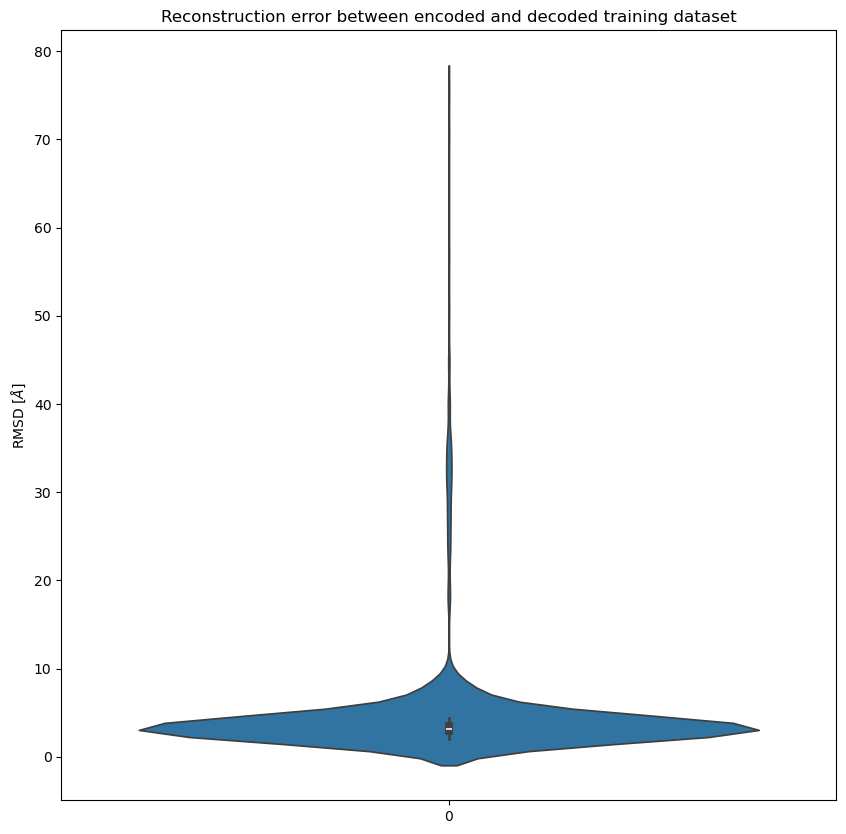

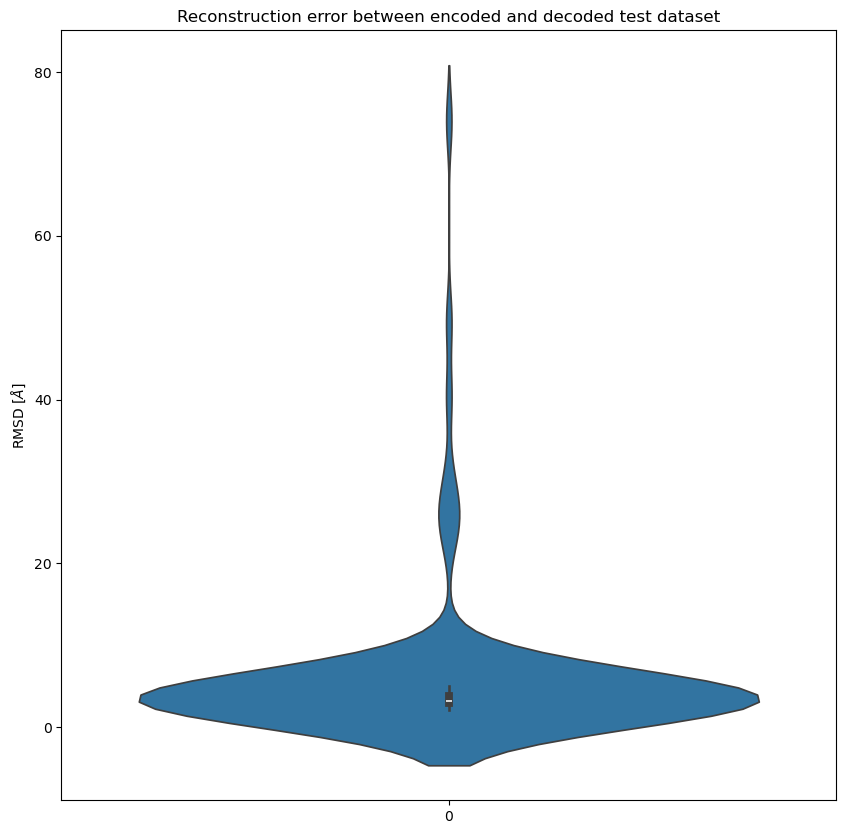

In [19]:

data = [err_train]
f = plt.figure(figsize=(10, 10))
sns.violinplot(data)
plt.ylabel('RMSD [$\AA$]')
plt.title('Reconstruction error between encoded and decoded training dataset')
plt.show()
f.savefig(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_train_{saveName}.png', dpi=300)

data = [err_test]
f = plt.figure(figsize=(10, 10))
sns.violinplot(data)
plt.ylabel('RMSD [$\AA$]')
plt.title('Reconstruction error between encoded and decoded test dataset')
plt.show()
f.savefig(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_test_{saveName}.png', dpi=300)

Copied outlier (train): Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/5I3O_B.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/rmsd_outliers_train/5I3O_B.pdb
Copied outlier (train): Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/3TV4_B.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/rmsd_outliers_train/3TV4_B.pdb
Copied outlier (train): Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/5I3R_A.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/rmsd_outliers_train/5I3R_A.pdb
Copied outlier (train): Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/4HW7_A.pdb -> Results/run_trial_BRAFActivationLoop_postalign_clea

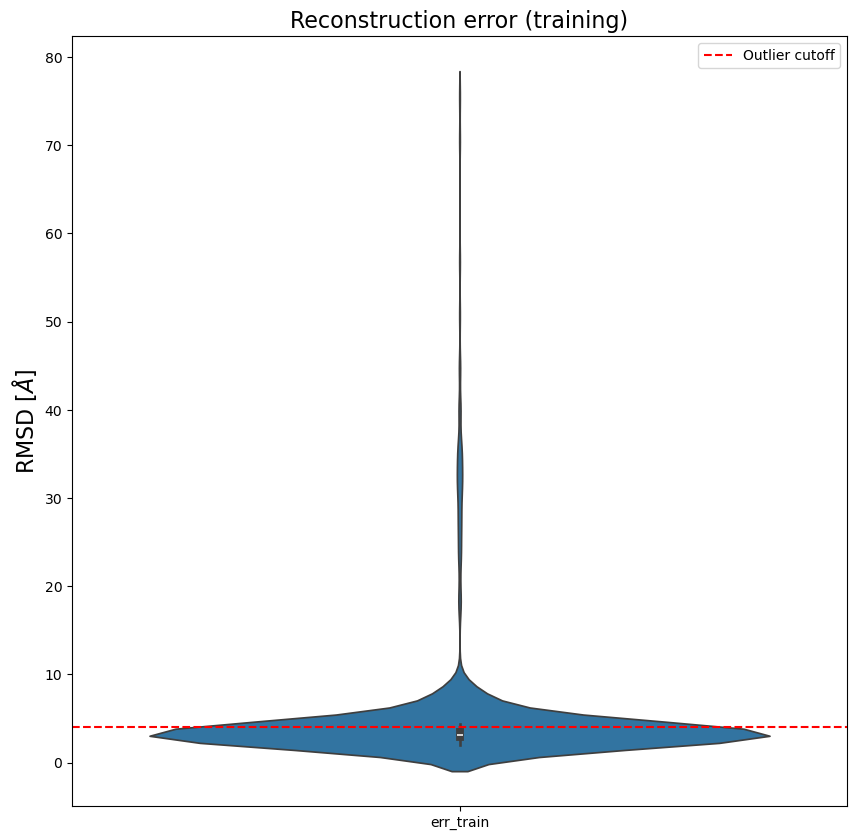

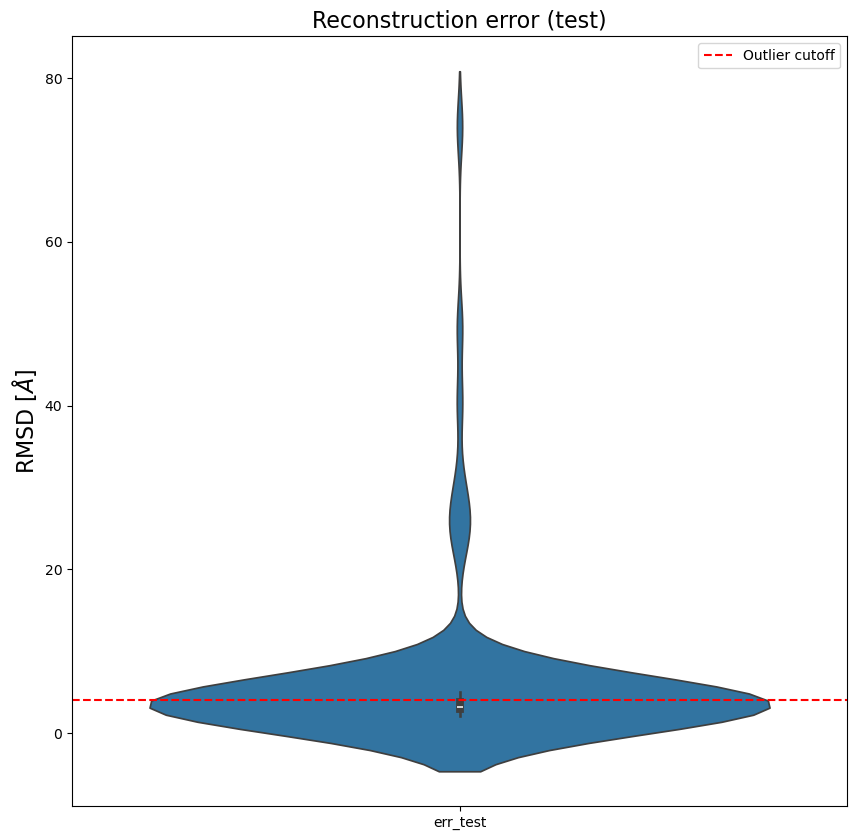

In [20]:
"""
This script filters out PDB structures with reconstruction errors above a 4 Å RMSD threshold, copies them into separate outlier folders for training and test sets, and visualizes the error distributions using violin plots.

"""
saveName = '_foldingnet_checkpoint'
train_err_csv = f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_train_{saveName}.csv'
test_err_csv = f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_test_{saveName}.csv'

# Load reconstruction errors from CSV
df_err_train = pd.read_csv(train_err_csv)   
df_err_test = pd.read_csv(test_err_csv)  

#Identify outlier indices with RMSD > 4
train_outlier_indices = df_err_train.index[df_err_train['err_train'] > 4].to_list()
test_outlier_indices = df_err_test.index[df_err_test['err_test'] > 4].to_list()

#Get sorted list of original PDB filenames
folder_name = 'Results/fitted_matlab_segments/mustang_endsAlignment_cleaned_noOutliers'
files = sorted([
    f for f in os.listdir(folder_name)
    if os.path.isfile(os.path.join(folder_name, f)) and f != 'combined.pdb'
])

#Create directories to store outlier PDB files
outlier_dir_train = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/rmsd_outliers_train'
outlier_dir_test = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/rmsd_outliers_test'
os.makedirs(outlier_dir_train, exist_ok=True)
os.makedirs(outlier_dir_test, exist_ok=True)

#Copy training outliers into designated folder
source_dir_train = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train'
for row_i in train_outlier_indices:
    frame_idx = train_indices[row_i]          
    original_filename = files[frame_idx]     

    src = os.path.join(source_dir_train, original_filename)
    dst = os.path.join(outlier_dir_train, original_filename)

    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f'Copied outlier (train): {src} -> {dst}')
    else:
        print(f'Skipping missing file (train): {src}')

#Copy test outliers into designated folder
source_dir_test = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test'
for row_i in test_outlier_indices:
    frame_idx = test_indices[row_i]
    original_filename = files[frame_idx]

    src = os.path.join(source_dir_test, original_filename)
    dst = os.path.join(outlier_dir_test, original_filename)

    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f'Copied outlier (test): {src} -> {dst}')
    else:
        print(f'Skipping missing file (test): {src}')

#Plot violin plot for training reconstruction errors
f = plt.figure(figsize=(10, 10))
sns.violinplot(data=[df_err_train['err_train']])
plt.axhline(y=4.0, color='red', linestyle='--', label='Outlier cutoff')
plt.legend()
plt.ylabel('RMSD [$\\AA$]', fontsize=16)
plt.title('Reconstruction error (training)', fontsize=16)
plt.show()
f.savefig(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_train_{saveName}.png', dpi=300)

#Plot violin plot for test reconstruction errors
f = plt.figure(figsize=(10, 10))
sns.violinplot(data=[df_err_test['err_test']])
plt.axhline(y=4.0, color='red', linestyle='--', label='Outlier cutoff')
plt.legend()
plt.ylabel('RMSD [$\\AA$]', fontsize=16)
plt.title('Reconstruction error (test)', fontsize=16)
plt.show()
f.savefig(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_test_{saveName}.png', dpi=300)


In [21]:
MA.setup_grid(30)
landscape_err_latent, landscape_err_3d, xaxis, yaxis = MA.scan_error()
df_landscape_err_latent = pd.DataFrame(landscape_err_latent)
df_landscape_err_latent.to_csv(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_latent_{saveName}.csv', index=False)

df_landscape_err_3d = pd.DataFrame(landscape_err_3d)
df_landscape_err_3d.to_csv(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_3d_{saveName}.csv', index=False)

df_xaxis = pd.DataFrame(xaxis)
df_xaxis.to_csv(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_xaxis_{saveName}.csv', index=False)

df_yaxis = pd.DataFrame(yaxis)
df_yaxis.to_csv(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_yaxis_{saveName}.csv', index=False)

Decoding grid:   0%|          | 0/113 [00:00<?, ?it/s]

Decoding grid:  14%|█▍        | 16/113 [00:00<00:00, 150.63it/s]

Decoding grid:  28%|██▊       | 32/113 [00:00<00:00, 150.55it/s]

Decoding grid:  42%|████▏     | 48/113 [00:00<00:00, 151.15it/s]

Decoding grid:  57%|█████▋    | 64/113 [00:00<00:00, 151.56it/s]

...

Decoding grid_decoded:  57%|█████▋    | 64/113 [00:00<00:00, 149.99it/s]

Decoding grid_decoded:  71%|███████   | 80/113 [00:00<00:00, 150.08it/s]

Decoding grid_decoded:  85%|████████▍ | 96/113 [00:00<00:00, 149.80it/s]

Decoding grid_decoded:  98%|█████████▊| 111/113 [00:00<00:00, 149.63it/s]

Decoding grid_decoded: 100%|██████████| 113/113 [00:00<00:00, 149.84it/s]

Projection into latent space.

In [22]:
with torch.no_grad():
    z = net.encode(data_train.dataset)

z_training = z.data.cpu().numpy()[:, :, 0]
df_z_train = pd.DataFrame(z_training)

df_z_train['train_index'] = train_indices

mapping_df = pd.read_csv('train_index_mapping_11_newsplit.csv') 
mapping_dict = mapping_df.set_index('train_index')['pdb_filename'].to_dict()

df_z_train['pdb_filename'] = df_z_train['train_index'].map(mapping_dict)

df_z_train.to_csv(
    f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_encoded_train_coordinates.csv',
    index=False
)


In [23]:
with torch.no_grad():
    z = net.encode(data_test.dataset)

z_test = z.data.cpu().numpy()[:, :, 0]
df_z_test = pd.DataFrame(z_test)

df_z_test['test_index'] = test_indices

test_mapping_df = pd.read_csv('test_index_mapping_11_newsplit.csv') 
test_mapping_dict = test_mapping_df.set_index('valid_index')['pdb_filename'].to_dict()

df_z_test['pdb_filename'] = df_z_test['test_index'].map(test_mapping_dict)

df_z_test.to_csv(
    f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_encoded_test_coordinates.csv',
    index=False
)

Train: 1204 / 1204
Test: 133 / 133


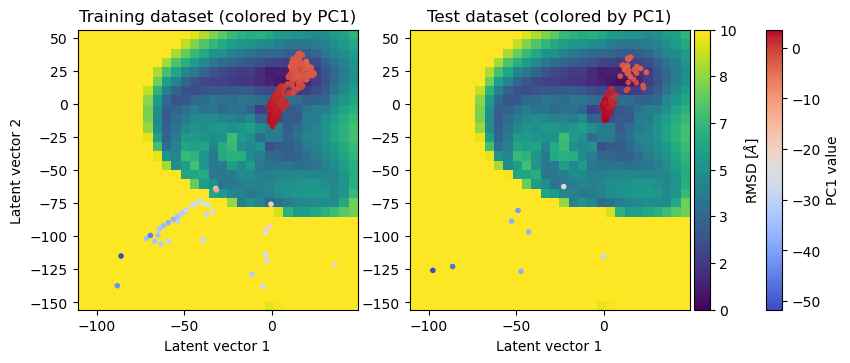

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

# Load precomputed latent space RMSD landscape (X, Y grid and Z values)
x_file = glob.glob("Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_xaxis__foldingnet_checkpoint.csv")
y_file = glob.glob("Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_yaxis__foldingnet_checkpoint.csv")
z_file = glob.glob("Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_latent__foldingnet_checkpoint.csv")

df_x = [pd.read_csv(file, header=None).to_numpy() for file in x_file]
df_y = [pd.read_csv(file, header=None).to_numpy() for file in y_file]
df_z = [pd.read_csv(file).to_numpy() for file in z_file]

df_z=np.squeeze(np.fliplr(df_z))

# Load PC1 values for each structure
pca_df = pd.read_csv(
    'pc1_ends_noOutliers.txt',
    delim_whitespace=True,
    comment='#',
    header=None,
    names=['PC1_value', 'pdb_filename']
)

pca_df['pdb_filename'] = pca_df['pdb_filename'].str.replace('.pdb', '', regex=False)

# Load latent coordinates and clean filenames
latent_train = pd.read_csv(
    'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_encoded_train_coordinates.csv'
)
latent_test = pd.read_csv(
    'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_encoded_test_coordinates.csv'
)

latent_train['pdb_filename'] = latent_train['pdb_filename'].str.replace('.pdb', '', regex=False)
latent_test['pdb_filename'] = latent_test['pdb_filename'].str.replace('.pdb', '', regex=False)

# Merge PC1 values into latent coordinate dataframes
merged_train = pd.merge(latent_train, pca_df, on='pdb_filename', how='inner')
merged_test = pd.merge(latent_test, pca_df, on='pdb_filename', how='inner')

print(f"Train: {len(merged_train)} / {len(latent_train)}")
print(f"Test: {len(merged_test)} / {len(latent_test)}")

# Extract coordinates and PC1 values
x_encoded_train = merged_train.iloc[:, 0]
y_encoded_train = merged_train.iloc[:, 1]
pc1_train = merged_train['PC1_value']

x_encoded_test = merged_test.iloc[:, 0]
y_encoded_test = merged_test.iloc[:, 1]
pc1_test = merged_test['PC1_value']

fig = plt.figure(figsize=(8, 8))

# Plot for training data
ax1 = fig.add_axes([0.0, 0.1, 0.35, 0.35])
ax1.imshow(df_z, cmap='viridis', vmin=0., vmax=10.,
           extent=[np.min(df_x), np.max(df_x), np.min(df_y), np.max(df_y)])
ax1.scatter(x_encoded_train, y_encoded_train, c=pc1_train, marker='.', cmap='coolwarm')
ax1.set_xlabel('Latent vector 1')
ax1.set_ylabel('Latent vector 2')
ax1.set_title('Training dataset (colored by PC1)')
ax1.set_aspect('auto')  

# Plot for test data
ax2 = fig.add_axes([0.415, 0.1, 0.35, 0.35])
im = ax2.imshow(df_z, cmap='viridis', vmin=0., vmax=10.,
                extent=[np.min(df_x), np.max(df_x), np.min(df_y), np.max(df_y)])
ax2.scatter(x_encoded_test, y_encoded_test, c=pc1_test, marker='.', cmap='coolwarm')
ax2.set_xlabel('Latent vector 1')
ax2.set_title('Test dataset (colored by PC1)')
ax2.set_aspect('auto')  


# RMSD colorbar
cbar_ax2 = fig.add_axes([0.77, 0.1, 0.02, 0.35])
cbar_ax2.tick_params(left=False, labelleft=False, right=True, labelright=True, labelbottom=False, bottom=False)
cbar = fig.colorbar(im, cax=cbar_ax2, label='RMSD [$\AA$]')
cbar_ticks = np.linspace(0, 10, 7)
cbar.set_ticks(cbar_ticks)
cbar.set_ticklabels([f'{tick:.0f}' for tick in cbar_ticks])

# PC1 colorbar
cbar_ax_pca = fig.add_axes([0.86, 0.1, 0.02, 0.35])
pca_norm = plt.Normalize(vmin=min(pc1_train.min(), pc1_test.min()),
                         vmax=max(pc1_train.max(), pc1_test.max()))
cbar_pca = fig.colorbar(
    plt.cm.ScalarMappable(norm=pca_norm, cmap='coolwarm'),
    cax=cbar_ax_pca,
    label='PC1 value'
)

plt.savefig(
    'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/RMSDlandscapesOnePlot_coloredByPC1.png',
    dpi=300, bbox_inches='tight'
)
plt.show()

Train匹配数量: 1204 / 1204
Test匹配数量: 133 / 133


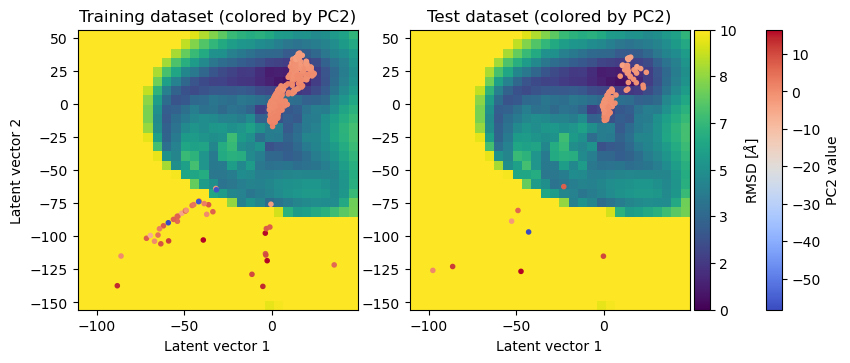

In [25]:
"""
Same as before but using PC2 to color the points 
"""
import pandas as pd
import matplotlib.pyplot as plt
import glob

x_file = glob.glob("Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_xaxis__foldingnet_checkpoint.csv")
y_file = glob.glob("Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_yaxis__foldingnet_checkpoint.csv")
z_file = glob.glob("Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_latent__foldingnet_checkpoint.csv")

df_x = [pd.read_csv(file, header=None).to_numpy() for file in x_file]
df_y = [pd.read_csv(file, header=None).to_numpy() for file in y_file]
df_z = [pd.read_csv(file).to_numpy() for file in z_file]

df_z=np.squeeze(np.fliplr(df_z))

pca_df = pd.read_csv(
    'pc2_ends_noOutliers.txt',
    delim_whitespace=True,
    comment='#',
    header=None,
    names=['PC1_value', 'pdb_filename']
)

pca_df['pdb_filename'] = pca_df['pdb_filename'].str.replace('.pdb', '', regex=False)

latent_train = pd.read_csv(
    'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_encoded_train_coordinates.csv'
)
latent_test = pd.read_csv(
    'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_encoded_test_coordinates.csv'
)

latent_train['pdb_filename'] = latent_train['pdb_filename'].str.replace('.pdb', '', regex=False)
latent_test['pdb_filename'] = latent_test['pdb_filename'].str.replace('.pdb', '', regex=False)

merged_train = pd.merge(latent_train, pca_df, on='pdb_filename', how='inner')
merged_test = pd.merge(latent_test, pca_df, on='pdb_filename', how='inner')

print(f"Train匹配数量: {len(merged_train)} / {len(latent_train)}")
print(f"Test匹配数量: {len(merged_test)} / {len(latent_test)}")

x_encoded_train = merged_train.iloc[:, 0]
y_encoded_train = merged_train.iloc[:, 1]
pc1_train = merged_train['PC1_value']

x_encoded_test = merged_test.iloc[:, 0]
y_encoded_test = merged_test.iloc[:, 1]
pc1_test = merged_test['PC1_value']

fig = plt.figure(figsize=(8, 8))

ax1 = fig.add_axes([0.0, 0.1, 0.35, 0.35])
ax1.imshow(df_z, cmap='viridis', vmin=0., vmax=10.,
           extent=[np.min(df_x), np.max(df_x), np.min(df_y), np.max(df_y)])
ax1.scatter(x_encoded_train, y_encoded_train, c=pc1_train, marker='.', cmap='coolwarm')
ax1.set_xlabel('Latent vector 1')
ax1.set_ylabel('Latent vector 2')
ax1.set_title('Training dataset (colored by PC2)')
ax1.set_aspect('auto')  

ax2 = fig.add_axes([0.415, 0.1, 0.35, 0.35])
im = ax2.imshow(df_z, cmap='viridis', vmin=0., vmax=10.,
                extent=[np.min(df_x), np.max(df_x), np.min(df_y), np.max(df_y)])
ax2.scatter(x_encoded_test, y_encoded_test, c=pc1_test, marker='.', cmap='coolwarm')
ax2.set_xlabel('Latent vector 1')
ax2.set_title('Test dataset (colored by PC2)')
ax2.set_aspect('auto')  

cbar_ax2 = fig.add_axes([0.77, 0.1, 0.02, 0.35])
cbar_ax2.tick_params(left=False, labelleft=False, right=True, labelright=True, labelbottom=False, bottom=False)
cbar = fig.colorbar(im, cax=cbar_ax2, label='RMSD [$\AA$]')
cbar_ticks = np.linspace(0, 10, 7)
cbar.set_ticks(cbar_ticks)
cbar.set_ticklabels([f'{tick:.0f}' for tick in cbar_ticks])

cbar_ax_pca = fig.add_axes([0.86, 0.1, 0.02, 0.35])
pca_norm = plt.Normalize(vmin=min(pc1_train.min(), pc1_test.min()),
                         vmax=max(pc1_train.max(), pc1_test.max()))
cbar_pca = fig.colorbar(
    plt.cm.ScalarMappable(norm=pca_norm, cmap='coolwarm'),
    cax=cbar_ax_pca,
    label='PC2 value'
)

plt.savefig(
    'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/RMSDlandscapesOnePlot_coloredByPC2.png',
    dpi=300, bbox_inches='tight'
)
plt.show()